In [87]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [88]:
df=pd.read_csv("../docs/oldDocs/Country-data.csv", na_values=[' ', '', '-', '/', 'NA', 'NULL'])

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [90]:
df.isna().sum()#vidimo da nemamo NAN vrednosti

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [91]:
#potrebno je da dropujemo ime zemlje jer ne doprinisi klasterizaciji
df.drop(columns='country',inplace=True)

In [92]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


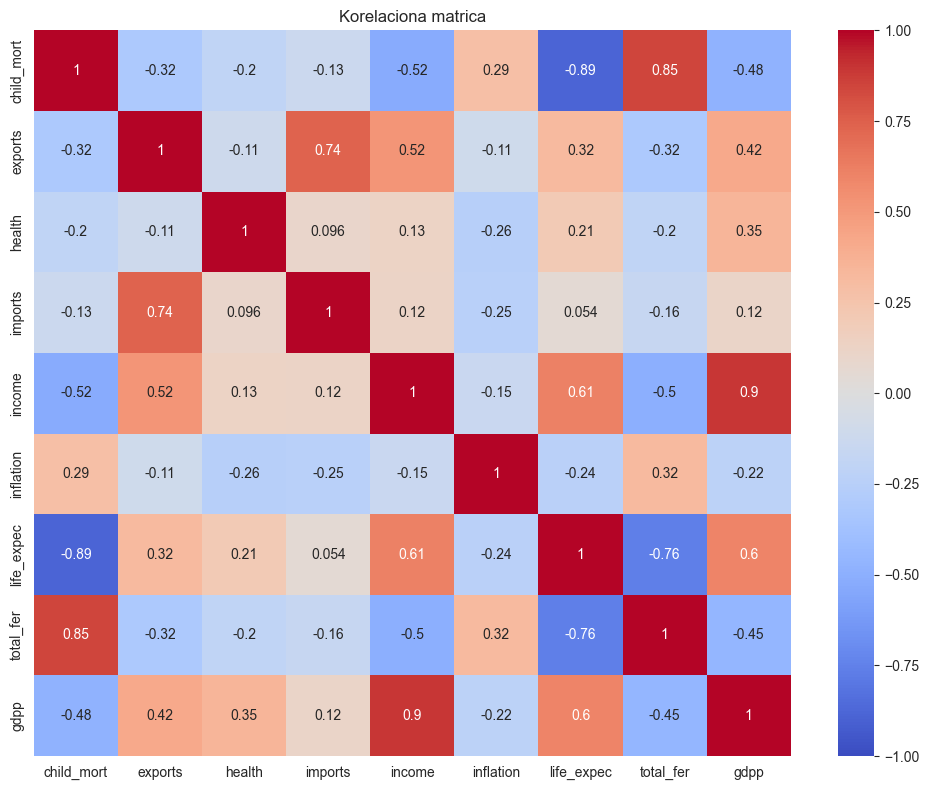

In [93]:
#moramo da uvedemo scaliranje ali prvo da proverimo korelaciju
import matplotlib.pyplot as plt
import seaborn as sb

corr_matrix = df.corr(numeric_only=True).round(2)
plt.figure(figsize=(10, 8))
sb.heatmap(df.corr(numeric_only=True), annot=True,
           cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Korelaciona matrica")
plt.tight_layout()
plt.show()

In [94]:
#neto prihod po stanvniku ima veliku korelaciju sa gdpp po stanovniku treba dropati jedno jer nam nije potrebno ajde gdpp
#veliki fertiliti cak 85 posto je korelisan sa brojem smrtnosti dece do 5 godina treba dropati smrtnost dece
#takodje je i child mortaliti dosta u vezi sa life expcetencijem
df.drop(columns='child_mort',inplace=True)
df.drop(columns='gdpp',inplace=True)

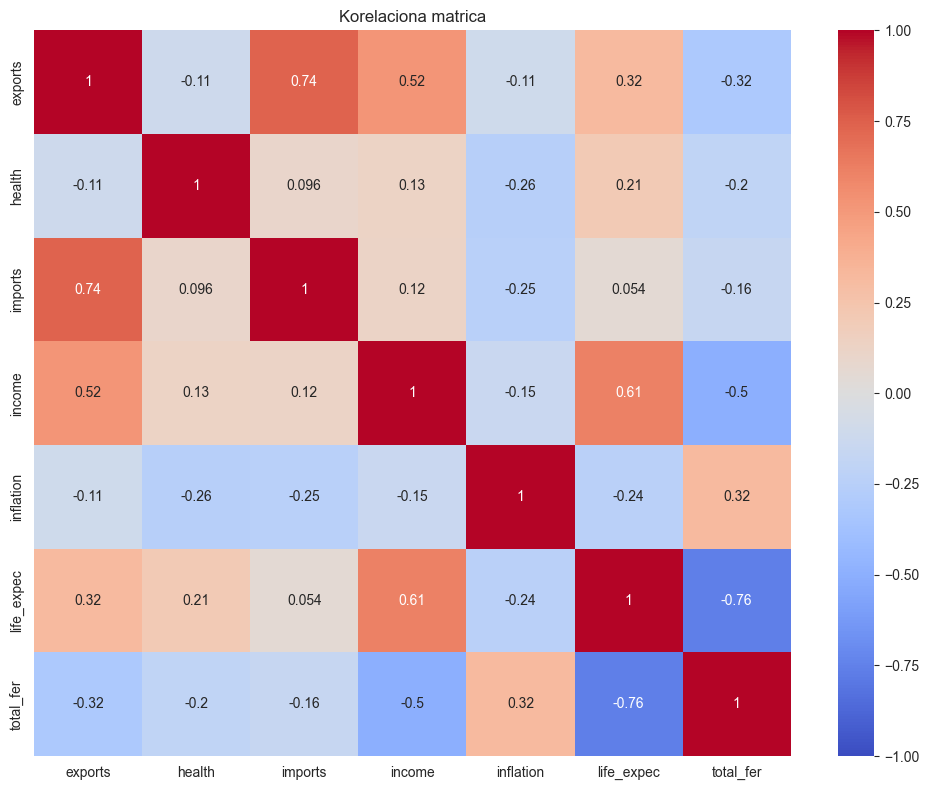

In [95]:
#moramo da uvedemo scaliranje ali prvo da proverimo korelaciju
import matplotlib.pyplot as plt
import seaborn as sb

corr_matrix = df.corr(numeric_only=True).round(2)
plt.figure(figsize=(10, 8))
sb.heatmap(df.corr(numeric_only=True), annot=True,
           cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Korelaciona matrica")
plt.tight_layout()
plt.show()

In [96]:
# i ocekivani zvitno vek je u velikoj vezi sa total fertility treba dropati fertility
df.drop(columns='total_fer',inplace=True)


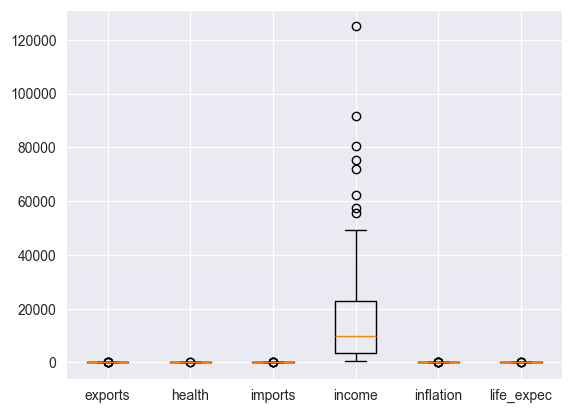

In [97]:
plt.figure()
plt.boxplot(x=df,tick_labels=df.columns)
plt.show()

#vidimo da veliki broj outliera ima income to bi trebalo da se sredi

In [98]:
from scipy.stats._mstats_basic import winsorize
for col in df.columns:
    wins=winsorize(df[col],limits=[0,0.05])
    df[col]=wins

In [99]:


#vidimo da veliki broj outliera ima income to bi trebalo da se sredi

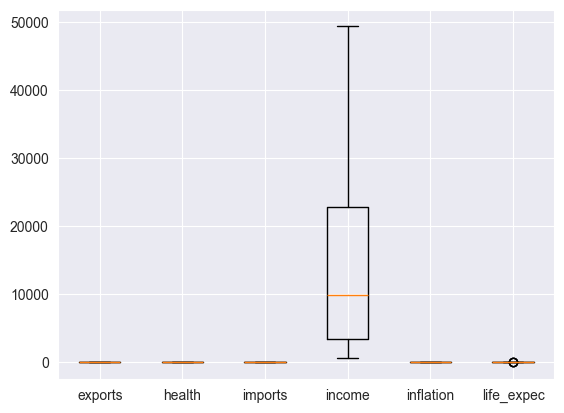

In [100]:
plt.figure()
plt.boxplot(x=df,tick_labels=df.columns)
plt.show()

#vidimo da veliki broj outliera ima income to bi trebalo da se sredi

In [110]:
wins=winsorize(df['life_expec'],limits=[0,0.1])
df['life_expec']=wins

In [111]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df_scaled=pd.DataFrame(data=scaler.fit_transform(df),columns=df.columns)

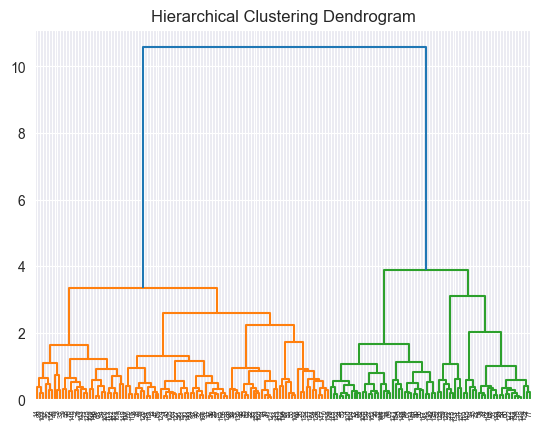

In [112]:
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram,linkage
plt.title("Hierarchical Clustering Dendrogram")
dendo=dendrogram(linkage(df_scaled,method='ward'))
plt.show()
#po slici vidimo da je optimalno da imamo 2 klustera

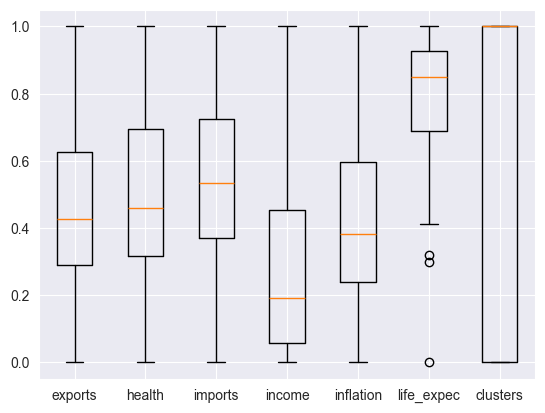

In [119]:
plt.figure()
plt.boxplot(x=df_scaled,tick_labels=df.columns)
plt.show()

#vidimo da veliki broj outliera ima income to bi trebalo da se sredi

In [114]:
model = AgglomerativeClustering(
        n_clusters=2,
        metric="euclidean",
        memory=None,
        connectivity=None,
        compute_full_tree="auto",
        linkage="ward",
        distance_threshold=None,
        compute_distances=False,)
clustering = model.fit(df_scaled)


In [115]:
df['clusters']=clustering.labels_

In [116]:
df['clusters'].value_counts()

clusters
1    99
0    68
Name: count, dtype: int64

In [117]:
print(df.groupby('clusters').std().round())

          exports  health  imports   income  inflation  life_expec
clusters                                                          
0            19.0     3.0     19.0  15643.0        5.0         5.0
1            15.0     2.0     17.0   7049.0        6.0         9.0


In [118]:
print(df.groupby('clusters').mean().round())

          exports  health  imports   income  inflation  life_expec
clusters                                                          
0            54.0     7.0     53.0  27496.0        3.0        76.0
1            29.0     6.0     40.0   7764.0        9.0        67.0


In [109]:
#vidimo da imamo 2 klastera 0 klaster je velicine 68

    # i njega cine zemlje sa velikim incomemom malom inflacijom i velikim life expcetinicijem  i velikikim exportom

#drugi klaster 1 cine 99 zemalja sa malim incomom i velikom inflacijom i manjim life expcetinticejem